# NLP Capstone Project: Fake News Classification

**Тема:** класифікація англомовних новин на `FAKE` та `REAL`  
**Датасет:** ISOT Fake News Dataset  
**Моделі:** TF-IDF + Logistic Regression, TF-IDF + Linear SVM, fine-tuned BERT

## Мета роботи

Метою проєкту є побудова та порівняння моделей бінарної класифікації новин за їхнім текстом.

Окрему увагу приділено методологічному обмеженню ISOT Dataset: більшість правдивих статей походять із Reuters, тоді як фейкові статті зібрані з інших джерел. Через це модель може вивчати стиль джерела, а не фактичну правдивість новини.

Тому в роботі:

1. видаляються точні дублікати до розбиття даних;
2. використовується єдиний stratified train/validation/test split;
3. оцінюються три моделі;
4. окремо виконується експеримент після видалення явних source markers;
5. аналізуються помилки `FAKE → REAL` та `REAL → FAKE`;
6. результати трактуються як **in-domain classification**, а не повноцінний fact-checking.

## 1. Встановлення та імпорт бібліотек

У Google Colab достатньо виконати клітинку нижче. Для локального запуску залежності також наведені у файлі `requirements.txt`.

In [7]:
!pip install -q pandas numpy matplotlib scikit-learn torch transformers accelerate datasets

In [8]:
import os
import re
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    matthews_corrcoef,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Середовище готове.")

Середовище готове.


## 2. Завантаження даних

Перед запуском покладіть `True.csv` та `Fake.csv` у поточну папку або завантажте їх у Google Colab.

In [9]:
TRUE_PATH = Path("True.csv")
FAKE_PATH = Path("Fake.csv")

if not TRUE_PATH.exists() or not FAKE_PATH.exists():
    raise FileNotFoundError(
        "Не знайдено True.csv або Fake.csv. "
        "Завантажте обидва файли ISOT Dataset у поточну папку."
    )

true_df = pd.read_csv(TRUE_PATH)
fake_df = pd.read_csv(FAKE_PATH)

true_df["label"] = 1
fake_df["label"] = 0

print(f"Правдивих статей: {len(true_df):,}")
print(f"Фейкових статей:  {len(fake_df):,}")
print("Колонки:", true_df.columns.tolist())

Правдивих статей: 21,417
Фейкових статей:  23,481
Колонки: ['title', 'text', 'subject', 'date', 'label']


## 3. Об'єднання, перевірка пропусків і дедуплікація

Дублікати видаляються **до** train/test split. Інакше однакова стаття може опинитися і в навчальній, і в тестовій вибірці та штучно підвищити метрики.

In [10]:
df = pd.concat([true_df, fake_df], ignore_index=True)

for column in ["title", "text", "subject", "date"]:
    if column not in df.columns:
        df[column] = ""

df[["title", "text", "subject", "date"]] = (
    df[["title", "text", "subject", "date"]].fillna("")
)

df["full_text_raw"] = (
    df["title"].str.strip() + ". " + df["text"].str.strip()
).str.strip()

def normalize_for_duplicates(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\W+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["duplicate_key"] = df["full_text_raw"].map(normalize_for_duplicates)

before = len(df)
df = df.drop_duplicates(subset=["duplicate_key"]).reset_index(drop=True)
removed = before - len(df)

print(f"Рядків до дедуплікації: {before:,}")
print(f"Видалено дублікатів:    {removed:,}")
print(f"Рядків після очищення:  {len(df):,}")
print("\nБаланс класів:")
print(df["label"].value_counts())

Рядків до дедуплікації: 44,898
Видалено дублікатів:    6,069
Рядків після очищення:  38,829

Баланс класів:
label
1    20928
0    17901
Name: count, dtype: int64


## 4. Розвідувальний аналіз даних

Перевіряємо:

- баланс класів;
- довжину текстів;
- розподіл тем за класами;
- зв'язок поля `subject` із цільовою змінною.

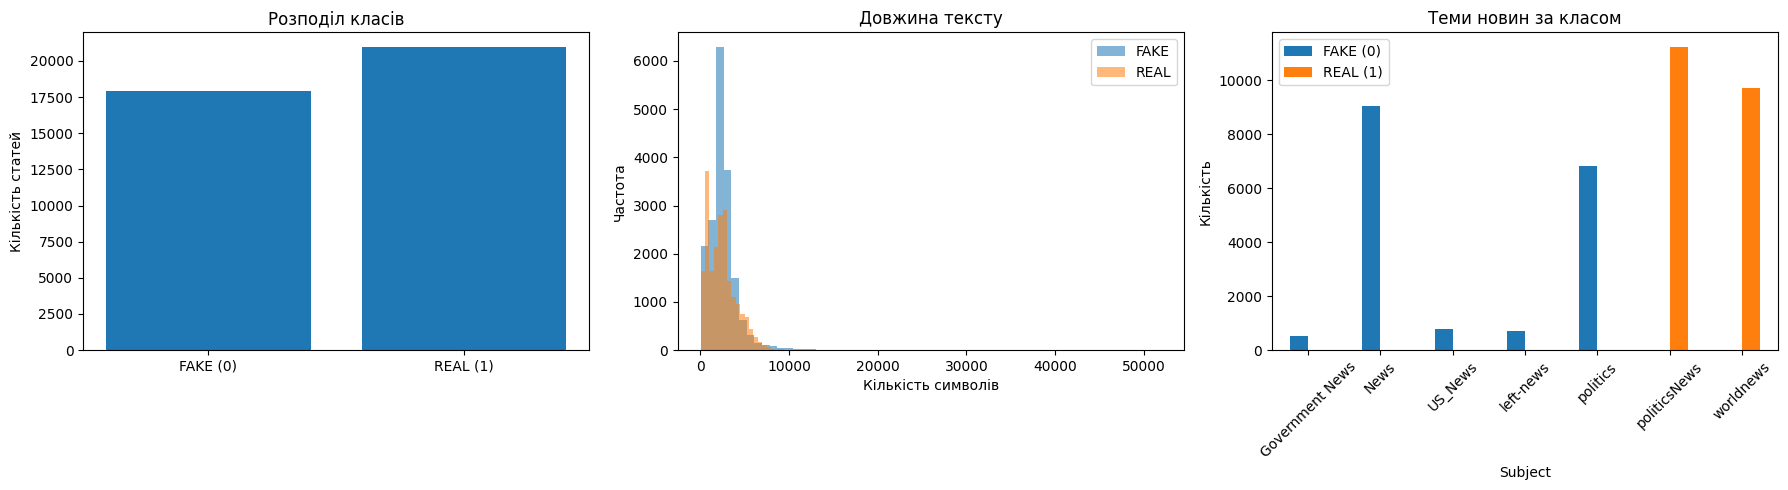

label,0,1
subject,,
Government News,531,0
News,9050,0
US_News,783,0
left-news,705,0
politics,6832,0
politicsNews,0,11216
worldnews,0,9712


In [11]:
df["text_len"] = df["full_text_raw"].str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

class_counts = df["label"].value_counts().sort_index()
axes[0].bar(["FAKE (0)", "REAL (1)"], class_counts.values)
axes[0].set_title("Розподіл класів")
axes[0].set_ylabel("Кількість статей")

for label, name in [(0, "FAKE"), (1, "REAL")]:
    axes[1].hist(
        df.loc[df["label"] == label, "text_len"],
        bins=60,
        alpha=0.55,
        label=name,
    )
axes[1].set_title("Довжина тексту")
axes[1].set_xlabel("Кількість символів")
axes[1].set_ylabel("Частота")
axes[1].legend()

subject_table = pd.crosstab(df["subject"], df["label"])
subject_table.plot(kind="bar", ax=axes[2])
axes[2].set_title("Теми новин за класом")
axes[2].set_xlabel("Subject")
axes[2].set_ylabel("Кількість")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(["FAKE (0)", "REAL (1)"])

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

display(subject_table)

## 5. Перевірка потенційного data leakage

У цьому датасеті клас може бути пов'язаний із джерелом і стилем статті. Це не класичний витік цільової мітки в ознаки, але сильний **dataset artifact**: модель може розпізнавати Reuters замість неправдивості.

In [12]:
source_patterns = {
    "Reuters": r"\bReuters\b",
    "21st Century Wire": r"21st\s+Century\s+Wire",
    "Infowars": r"\bInfowars\b",
    "Breitbart": r"\bBreitbart\b",
    "Featured image": r"featured\s+image",
    "Read more": r"read\s+more",
}

leakage_rows = []

for name, pattern in source_patterns.items():
    mask = df["full_text_raw"].str.contains(pattern, case=False, na=False, regex=True)
    leakage_rows.append({
        "marker": name,
        "fake_count": int(((df["label"] == 0) & mask).sum()),
        "real_count": int(((df["label"] == 1) & mask).sum()),
        "total": int(mask.sum()),
    })

leakage_table = pd.DataFrame(leakage_rows).sort_values("total", ascending=False)
display(leakage_table)

reuters_mask = df["full_text_raw"].str.contains(
    r"\bReuters\b", case=False, na=False, regex=True
)

real_reuters_share = reuters_mask[df["label"] == 1].mean() * 100
fake_reuters_share = reuters_mask[df["label"] == 0].mean() * 100

print(f"Частка REAL із маркером Reuters: {real_reuters_share:.2f}%")
print(f"Частка FAKE із маркером Reuters: {fake_reuters_share:.2f}%")

,marker,fake_count,real_count,total
0,Reuters,209,20890,21099
4,Featured image,8160,0,8160
5,Read more,1714,9,1723
3,Breitbart,773,100,873
1,21st Century Wire,629,0,629
2,Infowars,89,2,91


Частка REAL із маркером Reuters: 99.82%
Частка FAKE із маркером Reuters: 1.17%


## 6. Очищення тексту

Створюються дві версії:

- `full_text`: базове очищення;
- `full_text_no_markers`: базове очищення плюс видалення явних source-specific markers.

Важливо: навіть після видалення слів `Reuters`, `Infowars` тощо стилістичні відмінності можуть залишитися. Тому назва `no_markers` точніша, ніж категоричне `no leakage`.

In [13]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def remove_source_markers(text: str) -> str:
    text = clean_text(text)

    # Повний Reuters dateline на початку статті:
    # WASHINGTON (Reuters) - ...
    text = re.sub(
        r"^[A-Z][A-Z\s.,'-]{1,60}\s*\(Reuters\)\s*[-—:]?\s*",
        " ",
        text,
        flags=re.IGNORECASE,
    )

    patterns = [
        r"\(Reuters\)",
        r"\bReuters\b",
        r"21st\s+Century\s+Wire",
        r"\bInfowars\b",
        r"\bBreitbart\b",
        r"\bDC\s+Clothesline\b",
        r"featured\s+image",
        r"read\s+more",
    ]

    for pattern in patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text).strip()
    return text


df["full_text"] = df["full_text_raw"].map(clean_text)
df["full_text_no_markers"] = df["full_text_raw"].map(remove_source_markers)

display(
    df[["full_text", "full_text_no_markers", "label"]].sample(
        min(3, len(df)), random_state=RANDOM_STATE
    )
)

,full_text,full_text_no_markers,label
18500,Iraq sends delegation to Iran 'to coordinate m...,Iraq sends delegation to Iran 'to coordinate m...,1
16507,Billionaire Babis scores big Czech election wi...,Billionaire Babis scores big Czech election wi...,1
20905,"Trump must be respected as U.S. president, say...","Trump must be respected as U.S. president, say...",1


## 7. Коректне розбиття train / validation / test

Розбивається **весь DataFrame**, а не окремі масиви. Завдяки цьому кожний текст, його `subject`, мітка та майбутній прогноз залишаються в одному рядку.

Пропорції:

- 70% train;
- 15% validation;
- 15% test.

In [14]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df["full_text"].values
X_val = val_df["full_text"].values
X_test = test_df["full_text"].values

X_train_nm = train_df["full_text_no_markers"].values
X_val_nm = val_df["full_text_no_markers"].values
X_test_nm = test_df["full_text_no_markers"].values

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print(f"Train:      {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test:       {len(test_df):,}")

print("\nЧастка REAL:")
print(f"Train:      {y_train.mean():.4f}")
print(f"Validation: {y_val.mean():.4f}")
print(f"Test:       {y_test.mean():.4f}")

Train:      27,180
Validation: 5,824
Test:       5,825

Частка REAL:
Train:      0.5390
Validation: 0.5390
Test:       0.5391


## 8. Функції оцінювання

У проєкті головним позитивним класом для оцінювання ризику обрано `FAKE = 0`.

Scikit-learn за замовчуванням вважає позитивним клас `1`, тому для precision, recall і F1 класу FAKE явно задається `pos_label=0`.

Додатково обчислюються:

- balanced accuracy;
- Matthews Correlation Coefficient;
- ROC-AUC для ймовірності класу REAL.

In [15]:
all_results = []

def evaluate_model(
    name: str,
    y_true,
    y_pred,
    y_proba_real=None,
    train_seconds=None,
):
    result = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_fake": precision_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),
        "recall_fake": recall_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),
        "f1_fake": f1_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "train_seconds": train_seconds,
    }

    if y_proba_real is not None:
        result["roc_auc"] = roc_auc_score(y_true, y_proba_real)
    else:
        result["roc_auc"] = np.nan

    all_results.append(result)

    print(f"\n{name}")
    print("-" * len(name))
    print(classification_report(
        y_true,
        y_pred,
        target_names=["FAKE", "REAL"],
        digits=4,
        zero_division=0,
    ))

    return result

## 9. Baseline 1: TF-IDF + Logistic Regression

In [16]:
logreg_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            strip_accents="unicode",
            token_pattern=r"(?u)\b\w\w+\b",
            min_df=3,
            max_df=0.98,
        ),
    ),
    (
        "clf",
        LogisticRegression(
            C=1.0,
            solver="liblinear",
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ),
])

start = time.perf_counter()
logreg_pipeline.fit(X_train, y_train)
logreg_seconds = time.perf_counter() - start

y_pred_lr = logreg_pipeline.predict(X_test)
y_proba_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

metrics_lr = evaluate_model(
    "TF-IDF + Logistic Regression",
    y_test,
    y_pred_lr,
    y_proba_lr,
    train_seconds=logreg_seconds,
)


TF-IDF + Logistic Regression
----------------------------
              precision    recall  f1-score   support

        FAKE     0.9940    0.9862    0.9901      2685
        REAL     0.9883    0.9949    0.9916      3140

    accuracy                         0.9909      5825
   macro avg     0.9911    0.9906    0.9908      5825
weighted avg     0.9909    0.9909    0.9909      5825



## 10. Baseline 2: TF-IDF + Linear SVM

`LinearSVC` не повертає ймовірності, тому використовується `CalibratedClassifierCV`.

In [17]:
svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            strip_accents="unicode",
            token_pattern=r"(?u)\b\w\w+\b",
            min_df=3,
            max_df=0.98,
        ),
    ),
    (
        "clf",
        CalibratedClassifierCV(
            LinearSVC(
                C=0.5,
                random_state=RANDOM_STATE,
                max_iter=5000,
            ),
            cv=3,
        ),
    ),
])

start = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
svm_seconds = time.perf_counter() - start

y_pred_svm = svm_pipeline.predict(X_test)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

metrics_svm = evaluate_model(
    "TF-IDF + Linear SVM",
    y_test,
    y_pred_svm,
    y_proba_svm,
    train_seconds=svm_seconds,
)


TF-IDF + Linear SVM
-------------------
              precision    recall  f1-score   support

        FAKE     0.9933    0.9959    0.9946      2685
        REAL     0.9965    0.9943    0.9954      3140

    accuracy                         0.9950      5825
   macro avg     0.9949    0.9951    0.9950      5825
weighted avg     0.9950    0.9950    0.9950      5825



## 11. Ablation experiment: Logistic Regression без явних source markers

Цей експеримент перевіряє, наскільки результат залежить від очевидних назв джерел і шаблонних редакційних фраз.

Він **не усуває всі можливі dataset artifacts**, оскільки стиль, тематика та структура джерел усе одно можуть відрізнятися.

In [18]:
logreg_no_markers = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            strip_accents="unicode",
            token_pattern=r"(?u)\b\w\w+\b",
            min_df=3,
            max_df=0.98,
        ),
    ),
    (
        "clf",
        LogisticRegression(
            C=1.0,
            solver="liblinear",
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ),
])

start = time.perf_counter()
logreg_no_markers.fit(X_train_nm, y_train)
logreg_nm_seconds = time.perf_counter() - start

y_pred_nm = logreg_no_markers.predict(X_test_nm)
y_proba_nm = logreg_no_markers.predict_proba(X_test_nm)[:, 1]

metrics_nm = evaluate_model(
    "TF-IDF + LogReg (source markers removed)",
    y_test,
    y_pred_nm,
    y_proba_nm,
    train_seconds=logreg_nm_seconds,
)


TF-IDF + LogReg (source markers removed)
----------------------------------------
              precision    recall  f1-score   support

        FAKE     0.9883    0.9769    0.9826      2685
        REAL     0.9804    0.9901    0.9853      3140

    accuracy                         0.9840      5825
   macro avg     0.9844    0.9835    0.9839      5825
weighted avg     0.9841    0.9840    0.9840      5825



## 12. Fine-tuning BERT

BERT навчається на тій самій train-вибірці та оцінюється на тому самому test split.

Для відтворюваності найкраща модель зберігається локально разом із tokenizer.

In [22]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    set_seed,
)

set_seed(RANDOM_STATE)

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=MAX_LEN,
        )
        encoding["labels"] = int(self.labels[idx])
        return encoding

train_dataset = NewsDataset(X_train, y_train)
val_dataset = NewsDataset(X_val, y_val)
test_dataset = NewsDataset(X_test, y_test)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_bert_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_fake": f1_score(
            labels, preds, pos_label=0, zero_division=0
        ),
        "recall_fake": recall_score(
            labels, preds, pos_label=0, zero_division=0
        ),
    }

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_fake",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_bert_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ],
)

start = time.perf_counter()

trainer.train()

bert_seconds = time.perf_counter() - start

trainer.save_model("./models/bert_fake_news")
tokenizer.save_pretrained("./models/bert_fake_news")

print(f"BERT training time: {bert_seconds:.1f} seconds")
print("Модель збережено.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Fake,Recall Fake
1,0.000024,0.015795,0.997253,0.997015,0.995158
2,0.000050,0.006308,0.998970,0.998883,0.999255
3,0.000007,0.000655,0.999828,0.999814,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT training time: 4126.6 seconds
Модель збережено.


In [23]:
bert_output = trainer.predict(test_dataset)

y_pred_bert = np.argmax(bert_output.predictions, axis=1)
y_proba_bert = F.softmax(
    torch.tensor(bert_output.predictions), dim=1
).numpy()[:, 1]

metrics_bert = evaluate_model(
    "Fine-tuned BERT",
    y_test,
    y_pred_bert,
    y_proba_bert,
    train_seconds=bert_seconds,
)


Fine-tuned BERT
---------------
              precision    recall  f1-score   support

        FAKE     0.9989    1.0000    0.9994      2685
        REAL     1.0000    0.9990    0.9995      3140

    accuracy                         0.9995      5825
   macro avg     0.9994    0.9995    0.9995      5825
weighted avg     0.9995    0.9995    0.9995      5825



In [25]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "/content/models/bert_fake_news"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

print("✅ Модель успішно завантажена")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Модель успішно завантажена


## 13. Зведена таблиця результатів

In [26]:
results_df = pd.DataFrame(all_results)

metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision_fake",
    "recall_fake",
    "f1_fake",
    "roc_auc",
    "mcc",
    "train_seconds",
]

results_df[metric_columns] = results_df[metric_columns].astype(float)

display(
    results_df.style.format({
        "accuracy": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "precision_fake": "{:.4f}",
        "recall_fake": "{:.4f}",
        "f1_fake": "{:.4f}",
        "roc_auc": "{:.4f}",
        "mcc": "{:.4f}",
        "train_seconds": "{:.1f}",
    })
)

results_df.to_csv("final_results.csv", index=False)

,model,accuracy,balanced_accuracy,precision_fake,recall_fake,f1_fake,mcc,train_seconds,roc_auc
0,TF-IDF + Logistic Regression,0.9909,0.9906,0.9940,0.9862,0.9901,0.9817,33.1,0.9991
1,TF-IDF + Linear SVM,0.9950,0.9951,0.9933,0.9959,0.9946,0.9900,33.4,0.9995
2,TF-IDF + LogReg (source markers removed),0.9840,0.9835,0.9883,0.9769,0.9826,0.9679,73.3,0.9986
3,Fine-tuned BERT,0.9995,0.9995,0.9989,1.0000,0.9994,0.9990,4126.6,1.0000


## 14. Confusion matrix та ROC-криві

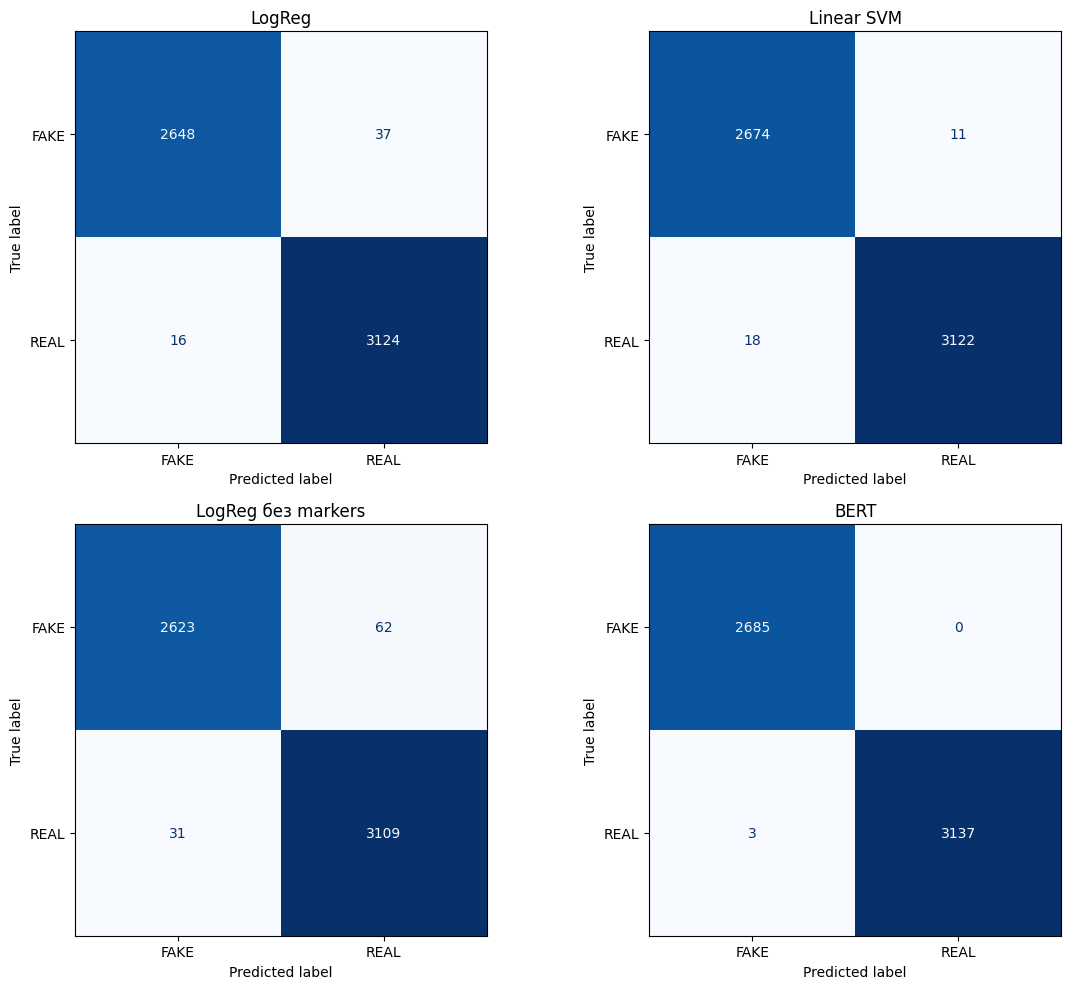

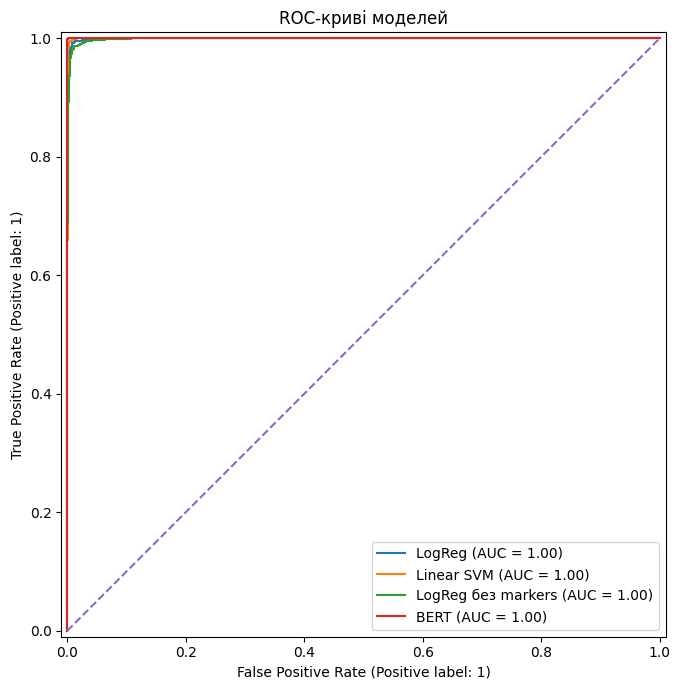

In [27]:
plot_models = [
    ("LogReg", y_pred_lr, y_proba_lr),
    ("Linear SVM", y_pred_svm, y_proba_svm),
    ("LogReg без markers", y_pred_nm, y_proba_nm),
    ("BERT", y_pred_bert, y_proba_bert),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, y_pred, _) in zip(axes.ravel(), plot_models):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["FAKE", "REAL"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 7))

for name, _, y_proba in plot_models:
    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=name,
        ax=plt.gca(),
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC-криві моделей")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Коректний аналіз помилок

Оскільки `FAKE = 0`:

- `FAKE → REAL`: фейкова стаття пропущена моделлю;
- `REAL → FAKE`: правдива стаття помилково позначена як фейкова.

Таке формулювання зрозуміліше за FP/FN, оскільки FP і FN залежать від вибору позитивного класу.

In [28]:
test_analysis = test_df.copy()
test_analysis["y_pred_lr"] = y_pred_lr
test_analysis["proba_real_lr"] = y_proba_lr

def describe_error(row):
    if row["label"] == 0 and row["y_pred_lr"] == 1:
        return "FAKE → REAL (пропущений фейк)"
    if row["label"] == 1 and row["y_pred_lr"] == 0:
        return "REAL → FAKE (правдива стаття заблокована)"
    if row["label"] == 0:
        return "FAKE → FAKE"
    return "REAL → REAL"

test_analysis["prediction_type"] = test_analysis.apply(
    describe_error, axis=1
)

print(test_analysis["prediction_type"].value_counts())

fake_as_real = test_analysis[
    (test_analysis["label"] == 0) &
    (test_analysis["y_pred_lr"] == 1)
].copy()

real_as_fake = test_analysis[
    (test_analysis["label"] == 1) &
    (test_analysis["y_pred_lr"] == 0)
].copy()

print("\nFAKE → REAL:")
display(
    fake_as_real[
        ["title", "subject", "proba_real_lr", "full_text"]
    ].head(5)
)

print("\nREAL → FAKE:")
display(
    real_as_fake[
        ["title", "subject", "proba_real_lr", "full_text"]
    ].head(5)
)

prediction_type
REAL → REAL                                  3124
FAKE → FAKE                                  2648
FAKE → REAL (пропущений фейк)                  37
REAL → FAKE (правдива стаття заблокована)      16
Name: count, dtype: int64

FAKE → REAL:


,title,subject,proba_real_lr,full_text
141,NEW LAW WILL PUNISH MUSLIM Migrants…Assimilate...,politics,0.618350,NEW LAW WILL PUNISH MUSLIM Migrants…Assimilate...
532,TRUMP TELLS State Department To Make CUT More ...,politics,0.742031,TRUMP TELLS State Department To Make CUT More ...
607,POPE TAKES COMMUNIST CRUCIFIX GIFT HOME: Says ...,left-news,0.526613,POPE TAKES COMMUNIST CRUCIFIX GIFT HOME: Says ...
649,BREAKING: TRUMP Announces “Phenomenal” Tax Cut...,politics,0.737799,BREAKING: TRUMP Announces “Phenomenal” Tax Cut...
751,WOW! Just When We Thought Obama’s Global Relat...,politics,0.654380,WOW! Just When We Thought Obama’s Global Relat...



REAL → FAKE:


,title,subject,proba_real_lr,full_text
53,Hackers play 30 minutes of Islamic State propa...,worldnews,0.393951,Hackers play 30 minutes of Islamic State propa...
543,Trump's 'obsession' with anchorwoman Kelly is ...,politicsNews,0.414898,Trump's 'obsession' with anchorwoman Kelly is ...
615,Conservatives bristle as Trump backs off Clint...,politicsNews,0.370796,Conservatives bristle as Trump backs off Clint...
907,Commentary: Manic or evasive - these veep guys...,politicsNews,0.219079,Commentary: Manic or evasive - these veep guys...
1133,Obama visits a mosque to send pointed message ...,politicsNews,0.412147,Obama visits a mosque to send pointed message ...


## 16. Інтерпретація Logistic Regression

Негативні коефіцієнти спрямовують прогноз до класу `FAKE = 0`, позитивні — до класу `REAL = 1`.

Якщо серед найважливіших ознак є назви джерел, редакційні шаблони або теми, це додатково підтверджує наявність dataset artifacts.

Ознаки, що спрямовують прогноз до FAKE:


,feature,coefficient
0,video,-9.050534
1,via,-8.258247
2,read more,-4.723207
3,image,-4.416185
4,just,-4.269068
5,this,-4.261742
6,featured image,-4.220826
7,featured,-4.186697
8,read,-4.143742
9,obama,-3.877486


Ознаки, що спрямовують прогноз до REAL:


,feature,coefficient
0,reuters,16.146450
1,said,9.345134
2,washington reuters,7.077276
3,said on,6.285610
4,washington,4.510061
5,reuters the,4.395906
6,on wednesday,4.340137
7,said in,4.197471
8,president donald,4.182605
9,on tuesday,4.158994


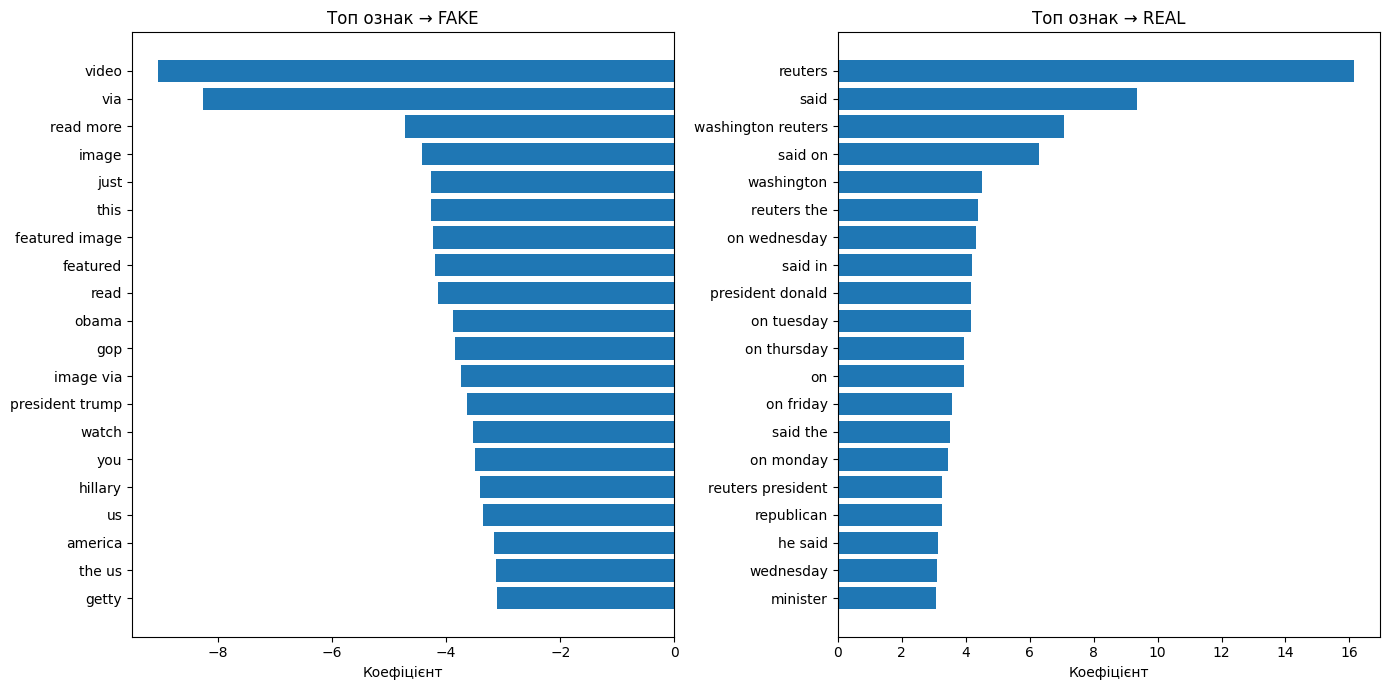

In [29]:
tfidf = logreg_pipeline.named_steps["tfidf"]
classifier = logreg_pipeline.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
coefficients = classifier.coef_[0]

top_n = 20

fake_indices = np.argsort(coefficients)[:top_n]
real_indices = np.argsort(coefficients)[-top_n:][::-1]

top_fake = pd.DataFrame({
    "feature": feature_names[fake_indices],
    "coefficient": coefficients[fake_indices],
})

top_real = pd.DataFrame({
    "feature": feature_names[real_indices],
    "coefficient": coefficients[real_indices],
})

print("Ознаки, що спрямовують прогноз до FAKE:")
display(top_fake)

print("Ознаки, що спрямовують прогноз до REAL:")
display(top_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top_fake["feature"], top_fake["coefficient"])
axes[0].invert_yaxis()
axes[0].set_title("Топ ознак → FAKE")
axes[0].set_xlabel("Коефіцієнт")

axes[1].barh(top_real["feature"], top_real["coefficient"])
axes[1].invert_yaxis()
axes[1].set_title("Топ ознак → REAL")
axes[1].set_xlabel("Коефіцієнт")

plt.tight_layout()
plt.savefig("top_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. Перевірка на нових текстах

Ручний тест не є повноцінною зовнішньою оцінкою, але може показати, що майже ідеальна test accuracy не гарантує генералізацію на нові джерела.

In [30]:
def predict_all(text: str):
    cleaned = clean_text(text)

    lr_proba = logreg_pipeline.predict_proba([cleaned])[0]
    svm_proba = svm_pipeline.predict_proba([cleaned])[0]

    device = next(trainer.model.parameters()).device
    encoded = tokenizer(
        cleaned,
        truncation=True,
        max_length=MAX_LEN,
        padding=True,
        return_tensors="pt",
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}

    trainer.model.eval()
    with torch.no_grad():
        logits = trainer.model(**encoded).logits
        bert_proba = torch.softmax(logits, dim=1)[0].cpu().numpy()

    rows = [
        {
            "model": "Logistic Regression",
            "fake_probability": lr_proba[0],
            "real_probability": lr_proba[1],
            "prediction": "REAL" if lr_proba[1] >= 0.5 else "FAKE",
        },
        {
            "model": "Linear SVM",
            "fake_probability": svm_proba[0],
            "real_probability": svm_proba[1],
            "prediction": "REAL" if svm_proba[1] >= 0.5 else "FAKE",
        },
        {
            "model": "BERT",
            "fake_probability": bert_proba[0],
            "real_probability": bert_proba[1],
            "prediction": "REAL" if bert_proba[1] >= 0.5 else "FAKE",
        },
    ]

    return pd.DataFrame(rows)

sample_text = (
    "The central bank announced that interest rates would remain unchanged "
    "after its latest policy meeting. Officials cited slower inflation and "
    "continued uncertainty in global markets."
)

display(predict_all(sample_text))

,model,fake_probability,real_probability,prediction
0,Logistic Regression,0.352576,0.647424,REAL
1,Linear SVM,0.810118,0.189882,FAKE
2,BERT,0.904366,0.095634,FAKE


## 18. Фінальні висновки

У межах проєкту було створено та порівняно три підходи до класифікації новин: Logistic Regression, Linear SVM та fine-tuned BERT.

Моделі можуть показувати дуже високі результати на випадково сформованій тестовій вибірці ISOT Dataset. Проте такі значення не слід трактувати як здатність автоматично перевіряти факти. У датасеті класи суттєво відрізняються за джерелами, тематикою, стилем і структурою тексту.

Експеримент із видаленням явних source markers показує, наскільки частина результату залежить від назв джерел і шаблонних фраз. Однак навіть після такого очищення стилістичні ознаки можуть залишатися, тому цей експеримент не доводить повну відсутність leakage.

Найкоректніше трактування результатів:

> моделі успішно розрізняють класи всередині ISOT Dataset, але їхню реальну здатність виявляти дезінформацію потрібно перевіряти на зовнішніх джерелах, часовому split або source-held-out split.

Для реального fake-news detection потрібні додаткові компоненти: claim extraction, пошук незалежних джерел, retrieval та перевірка тверджень, а не лише класифікація стилю тексту.